<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-14/NeuralNetworkCredit0609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Carregamento de Dados | Redes Neurais [Fase 1 - credit_data]

## Importar dados do Google Drive

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [23]:
!pip -q install plotly
!pip -q install yellowbrick

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_credit

In [25]:
import pickle

In [26]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/credit.pkl', mode = 'rb') as f:
   X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [27]:
X_credit_treinamento.shape, Y_credit_treinamento.shape

((1700, 3), (1700,))

In [28]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

# Pipeline Redes Neurais | [Fase 2 - credit_data]

In [37]:
from sklearn.neural_network import MLPClassifier

In [38]:
redeneural_credit = MLPClassifier(verbose = True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_credit.fit(X_credit_treinamento, Y_credit_treinamento)

Iteration 1, loss = 0.69502182
Iteration 2, loss = 0.61330999
Iteration 3, loss = 0.54489565
Iteration 4, loss = 0.48804341
Iteration 5, loss = 0.44173891
Iteration 6, loss = 0.40292910
Iteration 7, loss = 0.37002356
Iteration 8, loss = 0.34165605
Iteration 9, loss = 0.31696109
Iteration 10, loss = 0.29552313
Iteration 11, loss = 0.27628240
Iteration 12, loss = 0.25947110
Iteration 13, loss = 0.24404504
Iteration 14, loss = 0.23032767
Iteration 15, loss = 0.21808478
Iteration 16, loss = 0.20706886
Iteration 17, loss = 0.19699629
Iteration 18, loss = 0.18796378
Iteration 19, loss = 0.17979506
Iteration 20, loss = 0.17238176
Iteration 21, loss = 0.16560355
Iteration 22, loss = 0.15941385
Iteration 23, loss = 0.15374844
Iteration 24, loss = 0.14844230
Iteration 25, loss = 0.14355743
Iteration 26, loss = 0.13902980
Iteration 27, loss = 0.13488513
Iteration 28, loss = 0.13105098
Iteration 29, loss = 0.12744428
Iteration 30, loss = 0.12402670
Iteration 31, loss = 0.12095471
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [39]:
redeneural_credit.out_activation_

'logistic'

In [40]:
previsoes_redeneural = redeneural_credit.predict(X_credit_teste)
previsoes_redeneural

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

# Pipeline Medições Harmônicas | Redes Neurais [Fase 3 - credit_data]

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix

In [41]:
accuracy_score(Y_credit_teste, previsoes_redeneural)

0.9933333333333333

0.9933333333333333

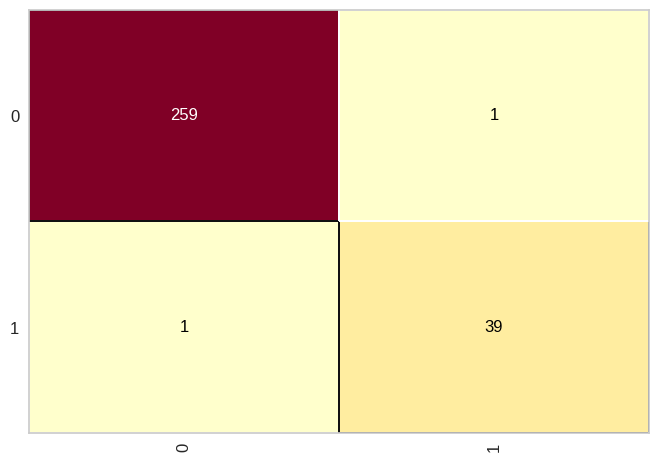

In [42]:
rn_cm = ConfusionMatrix(redeneural_credit)
rn_cm.fit(X_credit_treinamento, Y_credit_treinamento)
rn_cm.score(X_credit_teste, Y_credit_teste)

In [43]:
print(classification_report(Y_credit_teste, previsoes_redeneural))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       0.97      0.97      0.97        40

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

